<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/08_lognormal_distributional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 8 — Distributional lognormal model

Notebook 7 combined varying intercepts and slopes with a lognormal likelihood. Its participant-level posterior predictive check reproduced each participant's level and rate of change, but left one systematic mismatch: all participants shared a single residual scale `sd_y`, which was too large for the steadiest participants and too small for the most variable ones.

This notebook lets the residual scale differ by participant as well. The mean structure is Notebook 7's, unchanged, and is supplied. The new piece, a hierarchical model for the participants' residual scales, is built here step by step: why it lives on the log scale, what its priors mean, and how to read the fitted scales.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

participants = sorted(sleep["Subject"].unique(), key=int)
participant_to_idx = {participant: i for i, participant in enumerate(participants)}
participant_idx = sleep["Subject"].map(participant_to_idx).to_numpy()

assert participant_idx.min() == 0
assert participant_idx.max() == len(participants) - 1
assert np.array_equal(
    np.asarray(participants)[participant_idx],
    sleep["Subject"].to_numpy(),
)

print(f"{len(participants)} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


### Plotting helper

The participant plotting helper from the previous notebooks is supplied. It can optionally restrict plots to selected participants using the standard ArviZ `coords` argument. Panels appear in participant order (308, 309, …, 372), left to right and top to bottom.

In [4]:
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}

PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(
        sleep[["Subject", "Days"]],
        names=["participant", "day"],
    ),
    "obs_id",
)

def plot_participants(dt, group, var, coords=None):
    """One panel per participant, optionally restricted with ArviZ coords."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })

    pc = azp.plot_lm(
        panels,
        x="days",
        y=var,
        y_obs="y",
        group=group,
        plot_dim="day",
        coords=coords,
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        cols=["participant"],
        col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.add_legend("prob", title="HDI")
    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")
    return pc

## 1. Build the residual-scale hierarchy

### 1.1 The model

The model keeps Notebook 7's mean structure and gives each participant their own residual scale:

$$
y_i \sim \operatorname{LogNormal}(\mu_{y,i}, sd_{y,s[i]})
$$

$$
\mu_{y,i}
=
b_{0,s[i]}
+
b_{1,s[i]}\,\mathrm{days}_i
$$

$$
b_{0,s}
\sim
\operatorname{Normal}(\mu_{b0}, sd_{b0})
$$

$$
b_{1,s}
\sim
\operatorname{Normal}(\mu_{b1}, sd_{b1})
$$

$$
\log sd_{y,s}
\sim
\operatorname{Normal}(\mu_{\log sd_y}, sd_{\log sd_y}).
$$

Here $s[i]$ identifies the participant who produced observation $i$. The second, third, and fourth lines are Notebook 7's mean structure, unchanged. What is new is the residual scale: in the first line it now carries the participant subscript $s[i]$, and the last line gives the participants' residual scales a population distribution of their own.

A model in which a parameter of the likelihood other than its location, here the residual scale, has its own sub-model is called a **distributional** model.

### 1.2 The supplied mean structure

The data, coordinates, and mean structure are Notebook 7's, with the same prior constants, and are supplied. The model is created here without a residual scale or a likelihood. As in Notebook 4, you will add the remaining nodes in separate `with model:` blocks.

In [5]:
coords = {
    "obs_id": np.arange(len(sleep)),
    "participant": participants,
}

# Hyperprior constants for the intercept hierarchy (log reaction time), from Notebook 7
mu_mu_b0 = 5
sd_mu_b0 = 0.55
sd_sd_b0 = 1 / 6

# Hyperprior constants for the slope hierarchy (change in log reaction time per day),
# from Notebook 7
mu_mu_b1 = 0
sd_mu_b1 = 0.2
sd_sd_b1 = 0.05

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")
    pidx = pm.Data("participant_idx", participant_idx, dims="obs_id")

    # Varying intercepts
    mu_b0 = pm.Normal("mu_b0", mu=mu_mu_b0, sigma=sd_mu_b0)
    sd_b0 = pm.Exponential("sd_b0", scale=sd_sd_b0)
    b0 = pm.Normal("b0", mu=mu_b0, sigma=sd_b0, dims="participant")

    # Varying slopes
    mu_b1 = pm.Normal("mu_b1", mu=mu_mu_b1, sigma=sd_mu_b1)
    sd_b1 = pm.Exponential("sd_b1", scale=sd_sd_b1)
    b1 = pm.Normal("b1", mu=mu_b1, sigma=sd_b1, dims="participant")

    # Location of log reaction time
    mu_y = pm.Deterministic(
        "mu_y",
        b0[pidx] + b1[pidx] * days,
        dims="obs_id",
    )

### 1.3 What does $sd_{y,s}$ describe?

How does it differ from `sd_y` in Notebook 7?

It is participant $s$'s own residual scale: the standard deviation of that participant's log reaction time around **their own** trajectory, that is, how much their reaction times vary from day to day. As in Notebook 7, it acts proportionally: one residual standard deviation multiplies or divides that participant's median reaction time by $e^{sd_{y,s}}$.

In Notebook 7, one `sd_y` was shared by all participants. Now there are 18, one per participant, drawn from a population distribution, just as `b0` and `b1` are.

### 1.4 Why does the model describe $\log sd_{y,s}$ rather than $sd_{y,s}$ itself?

Recall why Notebook 6 modeled log reaction time.

A standard deviation must be positive. A Normal population distribution for the residual scales themselves could produce negative values, whereas any value of $\log sd_{y,s}$ gives a positive $sd_{y,s} = e^{\log sd_{y,s}}$. This is the same reason Notebook 6 modeled log reaction time: a positive quantity is unconstrained on the log scale.

It also makes differences between participants proportional: a participant one $sd_{\log sd_y}$ above the center has a residual scale $e^{sd_{\log sd_y}}$ times that of a typical participant.

### 1.5 What does $e^{\mu_{\log sd_y}}$ represent?

The residual scale of a **typical** participant: the median of the population distribution of participants' residual scales. As with $e^{\mu_y}$ in Notebook 6, exponentiating the center of a log-scale distribution gives a median, not a mean.

### 1.6 Why estimate the residual scales hierarchically?

Each participant contributes eight reaction times, which must also determine that participant's intercept and slope. Why not estimate 18 separate residual scales, one participant at a time?

A standard deviation estimated from eight observations around a fitted line is very uncertain: a participant who happened to have a few unusually consistent days would look implausibly steady, and one unusual day could make a participant look very variable. The hierarchy partially pools, as it does for `b0` and `b1`: each participant's residual scale is estimated from their own data but pulled toward the typical value, and the population parameters `mu_log_sd_y` and `sd_log_sd_y` are learned from all 18 participants together.

### 1.7 What would a prior centered at zero imply?

On the log scale, a prior centered at zero can look like a neutral default. What typical residual scale does $\mu_{\log sd_y} = 0$ correspond to, and what would it mean for a participant's reaction times?

$e^{0} = 1$, a residual scale of 1: one residual standard deviation would multiply or divide a participant's median reaction time by $e \approx 2.7$. A participant with a median of 300 ms would routinely produce reaction times near 110 ms and 800 ms under unchanged conditions.

Zero on the log scale is not an absence of information. Here it is a strong and implausible assumption, the same lesson as Notebook 6's mis-scaled priors.

### 1.8 What prior should we use for the typical residual scale?

Notebook 7 estimated a single residual scale shared by all participants, `sd_y` ≈ 0.08. Center the prior for $\mu_{\log sd_y}$ on the log of that value, and choose its standard deviation so that about 95% of the prior probability for the typical residual scale $e^{\mu_{\log sd_y}}$ lies between 0.03 and 0.22.

The center is $\log(0.08) \approx -2.5$. The limits are $\log(0.03) \approx -3.5$ and $\log(0.22) \approx -1.5$, so the range is $-2.5 \pm 2(0.5)$ on the log scale:

$$
\mu_{\log sd_y} \sim \operatorname{Normal}(-2.5, 0.5).
$$

A typical participant's day-to-day variation is then expected to lie between about 3% and 25% per residual standard deviation.

### 1.9 Notebook 7's estimate came from these same data. Is it legitimate to use it here?

Only with care, because it uses the same observations twice. It is defensible here because the prior takes only the order of magnitude from Notebook 7: its 95% range, 0.03–0.22, spans a factor of about seven, whereas Notebook 7's 90% HDI for `sd_y`, about 0.07–0.09, spans a factor of about 1.3. The data, not Notebook 7's estimate, will decide where in that range the typical residual scale lies; Question 4.4 checks this.

A center far from any plausible value, such as the zero of Question 1.7, would be a much stronger assumption, and a wrong one.

### 1.10 What prior should we use for the between-participant variation in residual scale?

$sd_{\log sd_y}$ is the between-participant standard deviation of the log residual scales. Suppose we use an Exponential prior with mean 1/3. At that value, how many times larger is the residual scale of a participant one standard deviation above the typical participant? How different are two participants two standard deviations either side of the center, roughly the steadiest and the most variable in a group of 18?

$$
sd_{\log sd_y} \sim \operatorname{Exponential}(\mathrm{scale}=1/3).
$$

At its mean, a participant one standard deviation above the typical participant has a residual scale $e^{1/3} \approx 1.4$ times as large. Two participants two standard deviations either side of the center differ by a factor of $e^{4/3} \approx 3.8$: the most variable participant's day-to-day variation would be a few times the steadiest one's. The Exponential prior also allows larger differences, but makes them progressively less likely.

### 1.11 Store the prior constants for the residual-scale hierarchy.

Assign the values from Questions 1.8 and 1.10 to `mu_mu_log_sd_y`, `sd_mu_log_sd_y`, and `sd_sd_log_sd_y`, following the naming pattern of the mean-structure constants.

In [6]:
# Hyperprior constants for the residual-scale hierarchy (log residual scale)
mu_mu_log_sd_y = -2.5
sd_mu_log_sd_y = 0.5
sd_sd_log_sd_y = 1 / 3

### 1.12 Add the population parameters of the residual-scale hierarchy.

In a `with model:` block, add the typical log residual scale `mu_log_sd_y` and the between-participant scale `sd_log_sd_y`, using the constants from Question 1.11.

In [7]:
with model:
    mu_log_sd_y = pm.Normal("mu_log_sd_y", mu=mu_mu_log_sd_y, sigma=sd_mu_log_sd_y)
    sd_log_sd_y = pm.Exponential("sd_log_sd_y", scale=sd_sd_log_sd_y)

### 1.13 Add each participant's residual scale.

Add `log_sd_y`, one value per participant drawn from the population distribution defined by `mu_log_sd_y` and `sd_log_sd_y`, in the same centered form as `b0` and `b1`. Then add the residual scales themselves as a `pm.Deterministic` named `sd_y`.

In [8]:
with model:
    log_sd_y = pm.Normal(
        "log_sd_y",
        mu=mu_log_sd_y,
        sigma=sd_log_sd_y,
        dims="participant",
    )
    sd_y = pm.Deterministic("sd_y", pm.math.exp(log_sd_y), dims="participant")

### 1.14 How does each observation get its participant's residual scale?

`sd_y` has one value per participant, but the likelihood needs one residual scale per observation.

By indexing with the participant index: `sd_y[pidx]` has one value per observation, the residual scale of the participant who produced it, exactly as `b0[pidx]` and `b1[pidx]` select each observation's intercept and slope in `mu_y`.

### 1.15 Complete the model.

Add the expected reaction time in milliseconds as a `pm.Deterministic` named `mean_rt`, now using each observation's participant-specific residual scale,

$$
\mathrm{E}[y_i] = \exp\!\left(\mu_{y,i} + \tfrac{1}{2}\,sd_{y,s[i]}^2\right),
$$

and the lognormal likelihood `y` for the observed reaction times.

In [9]:
with model:
    # Expected reaction time in milliseconds
    mean_rt = pm.Deterministic(
        "mean_rt",
        pm.math.exp(mu_y + sd_y[pidx] ** 2 / 2),
        dims="obs_id",
    )

    y = pm.LogNormal(
        "y",
        mu=mu_y,
        sigma=sd_y[pidx],
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

### 1.16 Inspect the completed model.

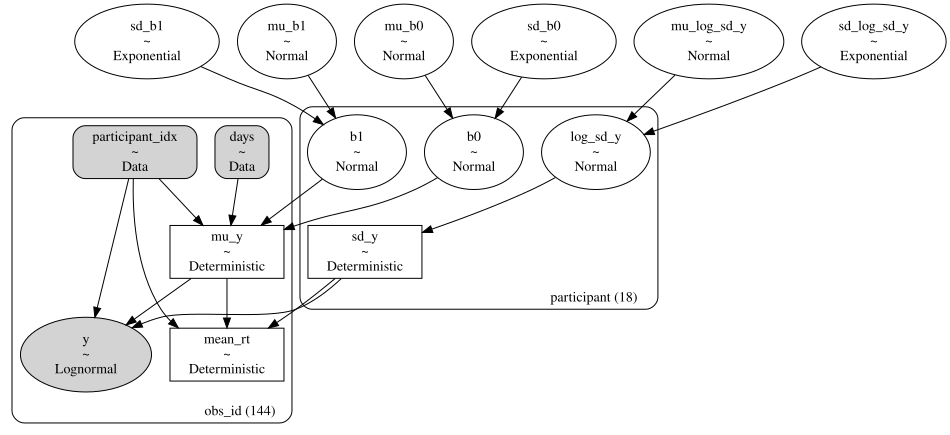

In [10]:
pm.model_to_graphviz(model)

### 1.17 Which nodes are new compared with Notebook 7's model?

Where does the residual-scale hierarchy enter the rest of the model?

The new nodes are `mu_log_sd_y` and `sd_log_sd_y`, and, in the participant plate, `log_sd_y` and `sd_y`: Notebook 7's single `sd_y` has moved into the participant plate. `sd_y` enters the rest of the model in two places: the likelihood `y`, where it is each observation's residual scale, and `mean_rt`, which now uses each participant's own residual scale.

## 2. Check the prior implications

### 2.1 Criteria

The prior predictions should meet the criteria established in Notebook 1: predicted reaction times should not routinely be physically impossible, reaction times near baseline should mostly occupy a broadly plausible range, and the model should allow substantial change across the seven days without routinely generating absurd trajectories. The mean-structure priors are Notebook 7's and were examined there.

The new criterion concerns the residual-scale hierarchy: it should allow participants to differ noticeably in day-to-day variability, without making residual scales near 1 (Question 1.7), or enormous differences between participants, routine.

### 2.2 Draw from the prior.

In [11]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["mu_log_sd_y", "sd_log_sd_y", "y"],
        random_seed=RANDOM_SEED,
    )

Sampling: [b0, b1, log_sd_y, mu_b0, mu_b1, mu_log_sd_y, sd_b0, sd_b1, sd_log_sd_y, y]


### 2.3 Plot the priors of the two residual-scale hyperparameters.

Use `azp.plot_dist` for `mu_log_sd_y` and `sd_log_sd_y`, with 90% HDIs and the mean as the point estimate.

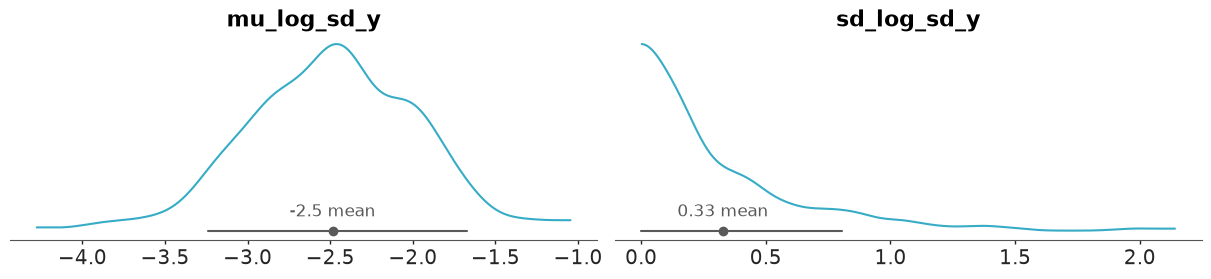

In [12]:
azp.plot_dist(
    prior,
    group="prior",
    var_names=["mu_log_sd_y", "sd_log_sd_y"],
    ci_prob=0.90,
    ci_kind="hdi",
    point_estimate="mean",
);

### 2.4 Are the residual-scale priors reasonable?

Translate each 90% HDI into residual scales, and into differences between participants.

Yes, broadly. The 90% HDI for `mu_log_sd_y` runs from about −3.2 to −1.7, so the typical participant's residual scale lies between about $e^{-3.2} \approx 0.04$ and $e^{-1.7} \approx 0.19$: day-to-day variation of a few percent to about 20%. A residual scale near 1 (Question 1.7) is effectively excluded.

`sd_log_sd_y` is mostly below about 0.8. At its mean, 1/3, participants' residual scales differ by a factor of about 1.4 per standard deviation. Near the upper end of the HDI, one standard deviation is a factor of $e^{0.8} \approx 2.2$, so the steadiest and most variable participants could differ twenty-fold or more. That upper end is generous, but the prior makes it unusual rather than routine.

### 2.5 Plot the prior predictive reaction times.

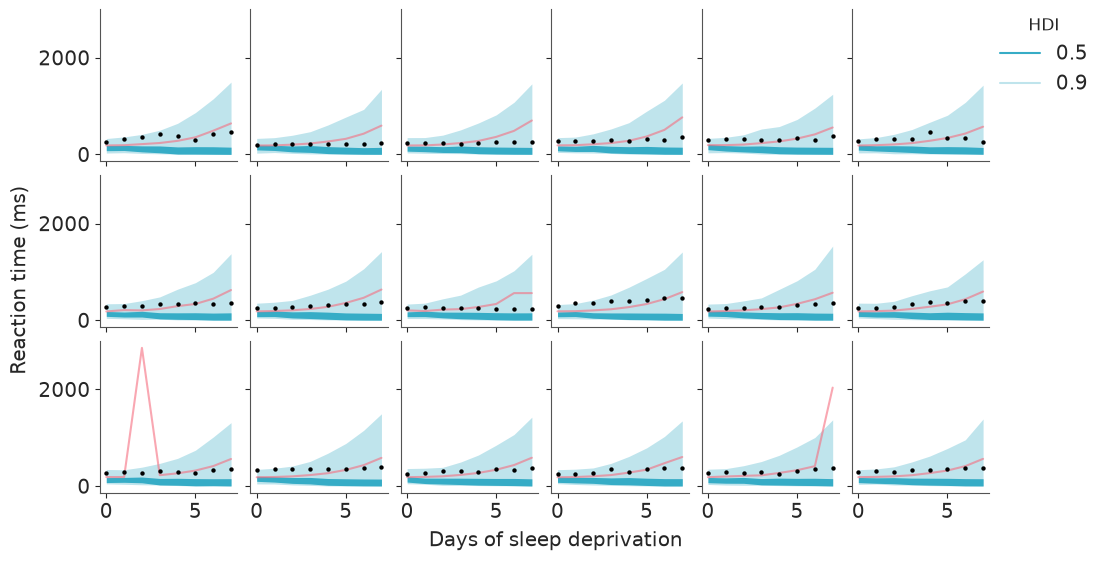

In [13]:
plot_participants(prior, "prior_predictive", "y")
plt.show()

### 2.6 Do these prior predictions meet the criteria established in Notebook 1?

Judge support, baseline scale, and changes across days, and compare with Notebook 7's prior predictive check.

Only partly, and much as in Notebook 7. Every prediction is a positive reaction time, and at baseline the 90% bands span roughly 30–350 ms. But the 50% bands end near 200 ms or below on every day, and every observed reaction time lies above its own panel's 50% band: the prior's most probable reaction times are implausibly fast, because Notebook 7's baseline prior is centered on a median of $e^{5} \approx 150$ ms. By day 7 the 50% band reaches almost zero and the 90% band extends to about 1.2–1.5 s, as uncertainty about the daily effect compounds.

These features come from the mean-structure priors, carried over unchanged from Notebook 7, where we accepted them as deliberately broad teaching priors. The new residual-scale priors barely change the bands.

### 2.7 What causes the single-day spikes?

In two panels the mean line spikes on a single day: participant 351 (third row, first panel) on day 2, and participant 371 (third row, fifth panel) on day 7. Which part of the model can produce a spike confined to one day, and which prior must be responsible?

Only the residual. A large intercept would raise that participant's whole trajectory, and a large slope would build up over several days. A spike on a single day, with ordinary values on the days around it, is one extreme reaction time in one draw, large enough to dominate the mean of that panel's 500 draws. To raise a mean of 500 draws by 1.5–2.5 s, a single draw must be roughly 750–1,300 s long: a "reaction time" of more than ten minutes.

The new hierarchy keeps the typical residual scale between a few percent and about 20%, so a residual this extreme needs one participant's residual scale to be drawn tens of times larger than the typical value. That is only plausible when `sd_log_sd_y` itself is drawn from the far upper tail of its prior, the generous upper end noted in Question 2.4; in these draws it exceeds 1.3. (The smaller step in participant 335's panel on day 6 has the same cause.)

### 2.8 Can these panels show whether the prior allows participants to differ in day-to-day variability?

No. Before seeing the data, participants are exchangeable (Notebook 7, Question 2.6): every panel shows the same prior predictive distribution, which mixes over all the residual scales the prior allows. Whether participants differ from one another is a property of each joint draw, not of any single panel, which is why Question 2.4 judged it from the prior for `sd_log_sd_y`.

## 3. Fit and diagnose the model

### 3.1 Sample from the posterior.

This model is sampled with `target_accept=0.9` instead of the default 0.8. Question 3.2 asks why.

In [14]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        target_accept=0.9,
        random_seed=RANDOM_SEED,
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [mu_b0, sd_b0, b0, mu_b1, sd_b1, b1, mu_log_sd_y, sd_log_sd_y, log_sd_y]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 10 seconds.


### 3.2 Why does this model need a higher `target_accept`?

With the default `target_accept` of 0.8, the sampler occasionally reports a divergence for this model, although Notebook 7's model sampled cleanly. A higher `target_accept` makes the sampler take smaller steps. Consider a steady participant such as 309: how precisely do its eight observations determine its intercept and slope when its residual scale is small, and when it is larger? Why could that make a single step size hard to choose?

When a participant's residual scale is small, their observations lie almost exactly on their trajectory and pin down the intercept and slope very precisely; when it is larger, the same observations allow a wider range of intercepts and slopes. Each participant's residual scale is itself uncertain, so the posterior for that participant's `b0` and `b1` is narrow in some regions and wider in others: a funnel shape. A step size that suits the wide regions can be too large for the narrow ones, which occasionally produces a divergence; smaller steps avoid this at a modest cost in speed.

Notebook 7 did not have this difficulty, because its single `sd_y` was pinned down by all 144 observations. It comes with the new construct: letting a scale parameter vary also changes the shape of the posterior for the parameters it scales.

### 3.3 Check population-level diagnostics.

In [15]:
print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))

azs.summary(
    idata,
    var_names=["mu_b0", "sd_b0", "mu_b1", "sd_b1", "mu_log_sd_y", "sd_log_sd_y"],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_b0,5.58,0.03,5.53,5.64,5215.04,3122.70,1.0,0.0,0.0
sd_b0,0.13,0.02,0.09,0.17,5180.70,3076.63,1.0,0.0,0.0
mu_b1,0.04,0.01,0.03,0.05,4544.39,3193.37,1.0,0.0,0.0
sd_b1,0.02,0.00,0.02,0.03,3794.71,3253.83,1.0,0.0,0.0
mu_log_sd_y,-2.85,0.15,-3.10,-2.62,4959.68,3526.34,1.0,0.0,0.0
sd_log_sd_y,0.59,0.12,0.40,0.80,3651.05,3152.71,1.0,0.0,0.0


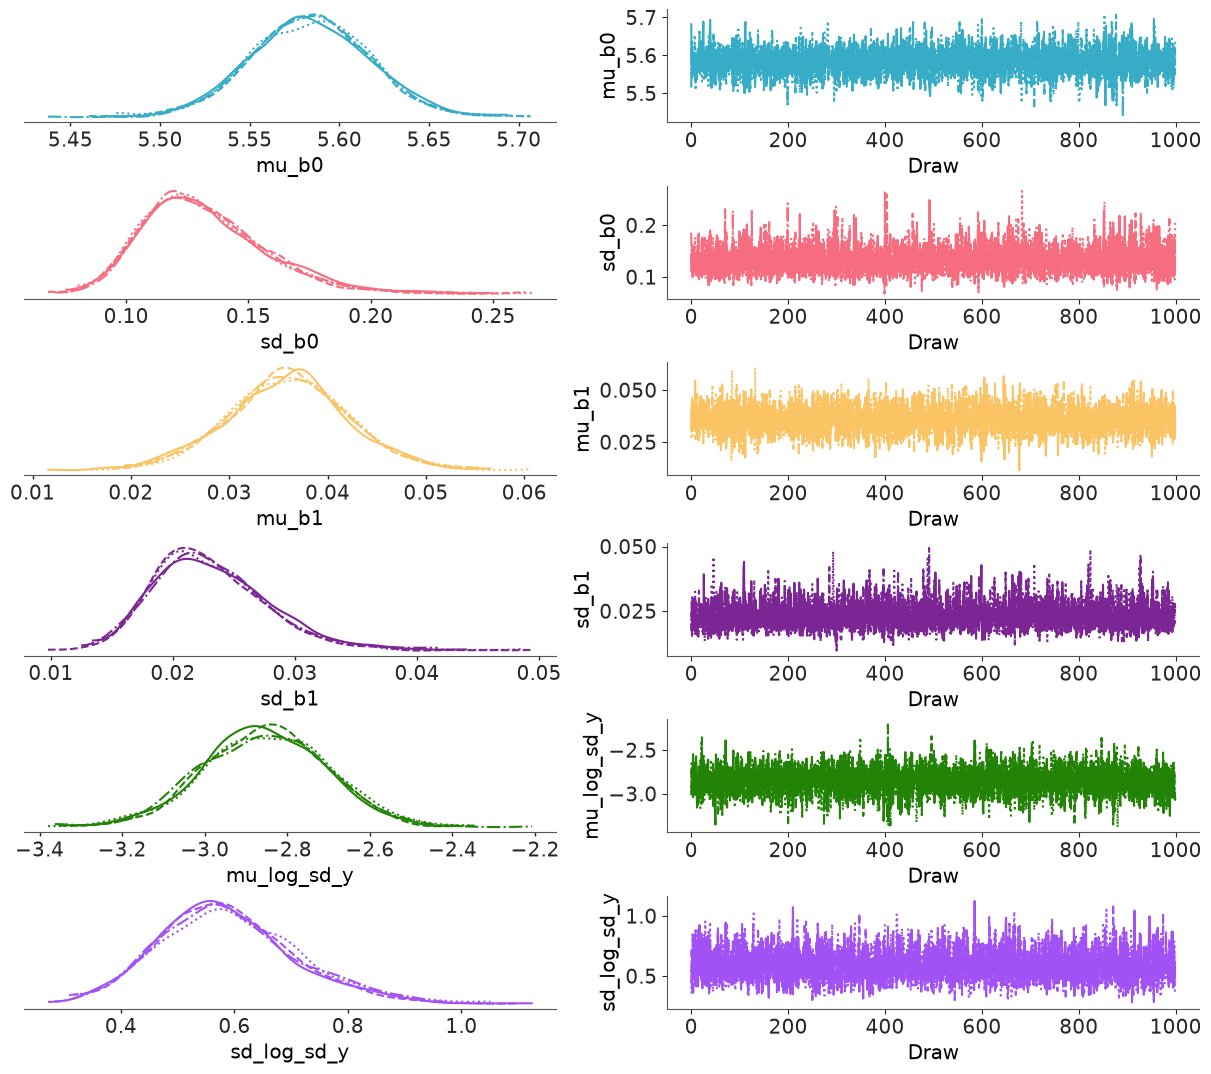

In [16]:
azp.plot_trace_dist(
    idata,
    var_names=["mu_b0", "sd_b0", "mu_b1", "sd_b1", "mu_log_sd_y", "sd_log_sd_y"],
);

### 3.4 Do the population-level parameters meet the diagnostic criteria?

Use the criteria established in Notebook 1: no divergences, R-hat close to 1, adequate bulk and tail ESS, and well-mixed traces.

Yes. There are no divergences, every population-level R-hat is 1.00, the bulk and tail ESS values are all in the thousands, and the traces show well-mixed chains, including those of the new parameters `mu_log_sd_y` and `sd_log_sd_y`. With the smaller steps, the centered parameterization samples reliably for the residual-scale hierarchy as well as for the mean structure.

### 3.5 Screen all participants, then inspect a representative subset.

In [17]:
participant_diagnostics = azs.summary(
    idata,
    var_names=["b0", "b1", "log_sd_y"],
    kind="diagnostics",
    round_to=2,
)

display(pd.DataFrame(
    {
        "value": [
            participant_diagnostics["r_hat"].max(),
            participant_diagnostics["ess_bulk"].min(),
            participant_diagnostics["ess_tail"].min(),
        ]
    },
    index=["largest R-hat", "smallest bulk ESS", "smallest tail ESS"],
))

diagnostic_participants = [
    participants[0],
    participants[len(participants) // 2],
    participants[-1],
]
diagnostic_coords = {"participant": diagnostic_participants}

azs.summary(
    idata,
    var_names=["b0", "b1", "log_sd_y"],
    coords=diagnostic_coords,
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

,value
largest R-hat,1.00
smallest bulk ESS,2707.34
smallest tail ESS,1813.21


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b0[308],5.68,0.07,5.57,5.78,4603.16,2936.27,1.0,0.0,0.0
b0[337],5.75,0.03,5.70,5.81,4412.31,3023.26,1.0,0.0,0.0
b0[372],5.67,0.03,5.62,5.72,4050.34,2758.72,1.0,0.0,0.0
b1[308],0.05,0.02,0.03,0.08,5225.76,3000.96,1.0,0.0,0.0
b1[337],0.06,0.01,0.05,0.07,5074.76,3104.27,1.0,0.0,0.0
b1[372],0.04,0.01,0.02,0.05,4061.32,2734.01,1.0,0.0,0.0
log_sd_y[308],-1.98,0.23,-2.37,-1.63,4700.91,2778.56,1.0,0.0,0.0
log_sd_y[337],-3.01,0.28,-3.48,-2.57,4721.99,3133.58,1.0,0.0,0.0
log_sd_y[372],-3.08,0.27,-3.53,-2.65,4021.72,2706.25,1.0,0.0,0.0


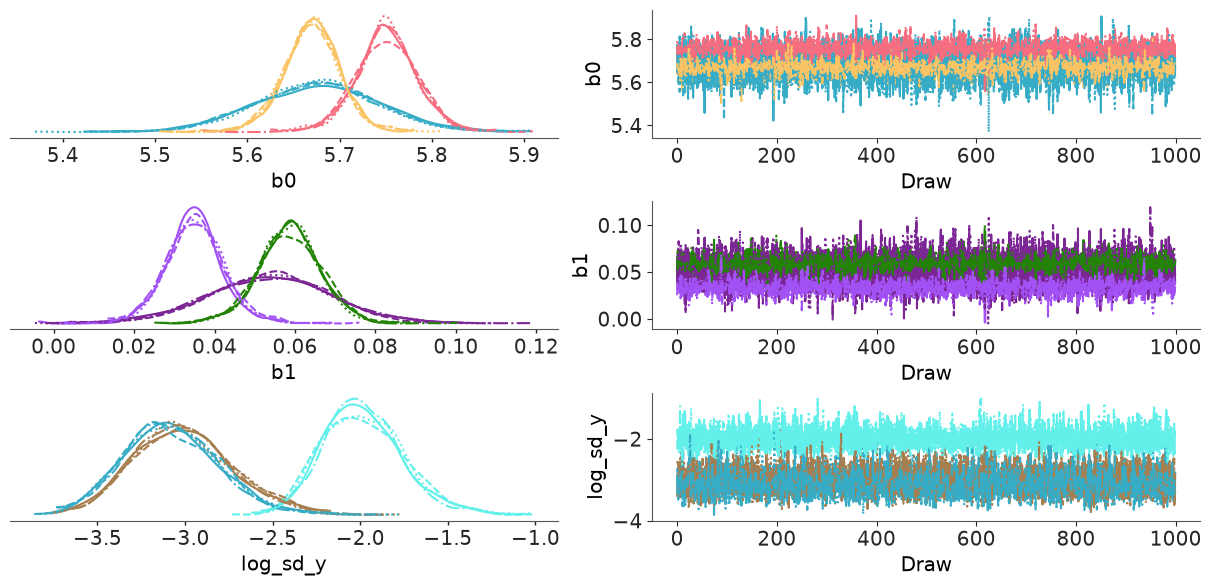

In [18]:
azp.plot_trace_dist(
    idata,
    var_names=["b0", "b1", "log_sd_y"],
    coords=diagnostic_coords,
);

### 3.6 Do the participant-level parameters meet the same criteria?

Yes. The all-participant screen, which now includes the 18 log residual scales, shows a largest R-hat of 1.00 and smallest bulk and tail ESS values well above 1,000, and the traces of `b0`, `b1`, and `log_sd_y` for participants 308, 337, and 372 mix well.

## 4. Examine the participant residual scales

### 4.1 Plot the posterior distributions of `mu_log_sd_y` and `sd_log_sd_y`.

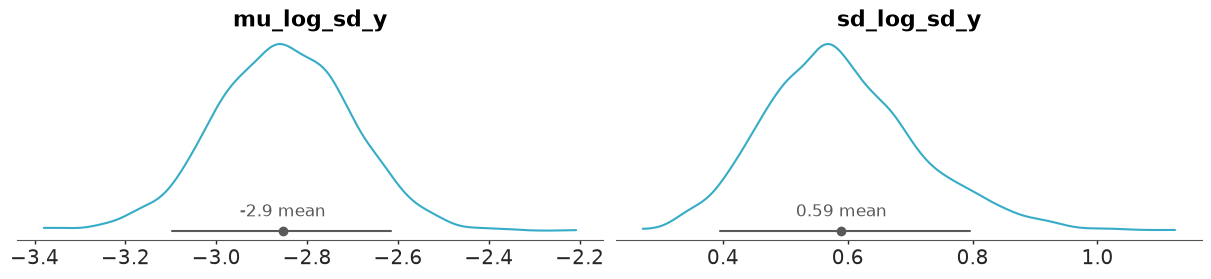

In [19]:
azp.plot_dist(
    idata,
    var_names=["mu_log_sd_y", "sd_log_sd_y"],
    ci_prob=0.90,
    ci_kind="hdi",
    point_estimate="mean",
);

### 4.2 What residual scale does a typical participant have?

Convert the 90% HDI for `mu_log_sd_y` from the summary in Question 3.3 into a residual scale, and compare it with Notebook 7's shared `sd_y`, about 0.08 (90% HDI roughly 0.07–0.09).

The 90% HDI for `mu_log_sd_y` is approximately **−3.1 to −2.6**, so the typical participant's residual scale is between about $e^{-3.1} \approx 0.045$ and $e^{-2.6} \approx 0.075$: one residual standard deviation changes a typical participant's reaction time by roughly **4.5–7.5%**.

That is smaller than Notebook 7's shared `sd_y`. A single shared scale had to describe every participant's residuals, so it was pulled up by the most variable participants. $e^{\mu_{\log sd_y}}$ is the residual scale of the median participant, and most participants are steadier than the shared value suggested.

### 4.3 How much do residual scales differ between participants?

Use the 90% HDI for `sd_log_sd_y`. By what factor does one standard deviation change a participant's residual scale?

The 90% HDI for `sd_log_sd_y` is approximately **0.4–0.8**, so a participant one standard deviation above the typical participant has a residual scale about $e^{0.4} \approx 1.5$ to $e^{0.8} \approx 2.2$ times as large. Across the group, residual scales therefore differ several-fold between the steadiest and the most variable participants.

### 4.4 How far did the data move these two parameters from their priors?

Compare your plot in Question 4.1 with the prior plot in Question 2.3.

For `mu_log_sd_y`, substantially: the 90% HDI narrowed from about −3.2 to −1.7 in the prior to about −3.1 to −2.6, roughly a third of the width, and the posterior center, about −2.9, lies below the prior center of −2.5. The typical residual scale is determined mainly by the data, not by Notebook 7's estimate (Question 1.9).

For `sd_log_sd_y`, the posterior lies in the upper part of the prior: values below about 0.4, which the prior considered most likely, are ruled out, so the participants differ in variability more than the prior expected. Because the Exponential prior favors small values, if anything it pulls this estimate down; the evidence for differences between participants does not come from the prior.

### 4.5 Plot each participant's residual scale.

Use `azp.plot_forest` for `sd_y`, with 50% and 90% HDIs.

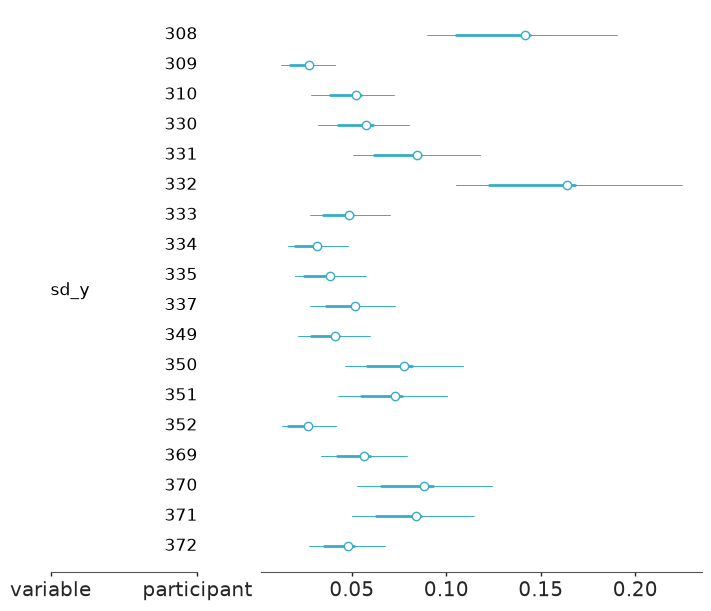

In [20]:
azp.plot_forest(
    idata,
    var_names=["sd_y"],
    combined=True,
    ci_probs=(0.50, 0.90),
    ci_kind="hdi",
    figure_kwargs={"figsize": (7, 6)},
);

### 4.6 Does the fitted model support meaningful differences in residual scale between participants?

Base the answer on the participant intervals and the posterior for `sd_log_sd_y`, and express the difference between the steadiest and the most variable participants in milliseconds.

Yes. The posterior for `sd_log_sd_y` is well away from zero, and the participant intervals occupy clearly different regions. The steadiest participants, 309 and 352, have residual scales of about 0.03 (90% HDIs roughly 0.01–0.04), while the most variable, 308 and 332, have about 0.14 and 0.16 (90% HDIs roughly 0.09–0.23): a five- to six-fold difference, with no overlap between the intervals.

At a reaction time of 300 ms, one residual standard deviation is roughly ±8 ms for the steadiest participants and roughly ±45 ms for the most variable. Most participants lie between, around the typical value of Question 4.2.

## 5. Predictive consequences

### 5.1 Plot each participant's posterior expected reaction time.

Use `plot_participants` with the variable that gives the expected reaction time in milliseconds.

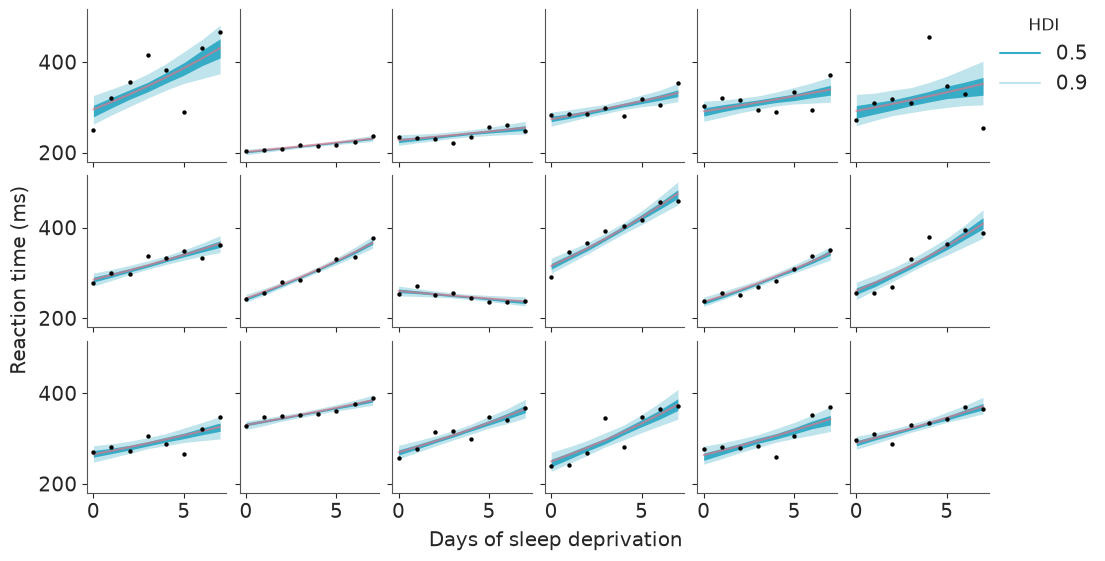

In [21]:
plot_participants(idata, "posterior", "mean_rt")
plt.show()

### 5.2 How do these expected trajectories compare with Notebook 7's?

Compare with the corresponding plot in Notebook 7 (its Question 5.1). Look separately at the mean lines and at the widths of the bands, which show uncertainty about each participant's expected reaction time.

The mean lines are almost unchanged: letting the residual scale vary barely changes what the model expects each participant's reaction time to be. The band widths have changed. How precisely a participant's trajectory can be estimated depends on how noisy that participant's observations are, and the model now takes this into account: participant 309's band (first row, second panel) has shrunk to little more than a line, while the bands of the most variable participants, 308 and 332 (first row, first and sixth panels), are wider than in Notebook 7.

Where a mean line has moved, the reason is related. Participants with noisy data now borrow more from the population, so participant 332's slope is pulled toward the population average and its trajectory is slightly steeper, while steady participants' slopes rest more on their own data.

### 5.3 Generate and plot posterior predictive reaction times.

Generate replicated values of `y` from the fitted model, add them to `idata`, and compare them with the observations using `plot_participants`.

Sampling: [y]


Output()

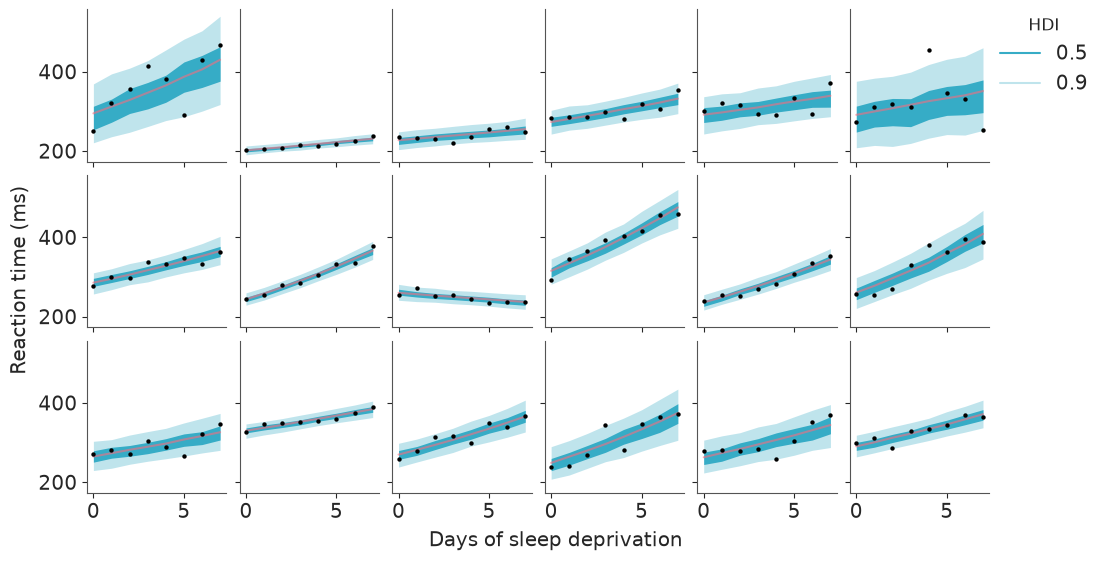

In [22]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["y"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

plot_participants(idata, "posterior_predictive", "y")
plt.show()

### 5.4 What is added when we move from `mean_rt` to posterior predictive `y`, and what is new about it in this model?

Residual day-to-day variation. As in Notebook 7 it is multiplicative, so in milliseconds the bands are wider where a participant's reaction times are longer. What is new is that its size is now each participant's own `sd_y`: participant 309's 90% predictive band is only about 25 ms wide, while those of participants 308 and 332 are about 150–220 ms wide. In Notebook 7, all participants' bands had comparable widths, about 60–130 ms, differing only with the level of their reaction times.

### 5.5 Does the model reproduce the participant-level data, and does it resolve the mismatch Notebook 7 left?

Apply the posterior predictive criteria from Notebook 1: participants' overall levels, changes across days, and residual variation, emphasizing discrepancies that persist across a participant's observations. In Notebook 7's check, the steadiest participants' observations sat well inside bands that were too wide, and the most variable participants' observations fell outside bands that were too narrow.

Yes. Levels and rates of change are reproduced as in Notebook 7, and the systematic mismatch in residual variation is gone: each participant's bands now match that participant's own day-to-day scatter. The observations of steady participants such as 309 now spread across narrow bands instead of clustering in the middle of wide ones, and the jumpy observations of 308 and 332 mostly fall inside their much wider bands.

Only isolated observations fall outside or at the edge of the 90% bands, most clearly participant 332's slow reaction time on day 4. They are single days, not a pattern that persists within a participant.

### 5.6 What would indicate adequate fit in an ECDF check?

The participant panels check conditional trajectories. Pooling all observations asks a different question: does the model reproduce the overall distribution of reaction times?

As in Notebooks 5–7, the observed ECDF should be broadly consistent with the posterior-predictive ECDFs across the whole distribution, without a persistent systematic displacement, particularly in the tails.

### 5.7 Plot the observed and posterior-predictive ECDFs.

Use `azp.plot_ppc_dist` with `kind="ecdf"`.

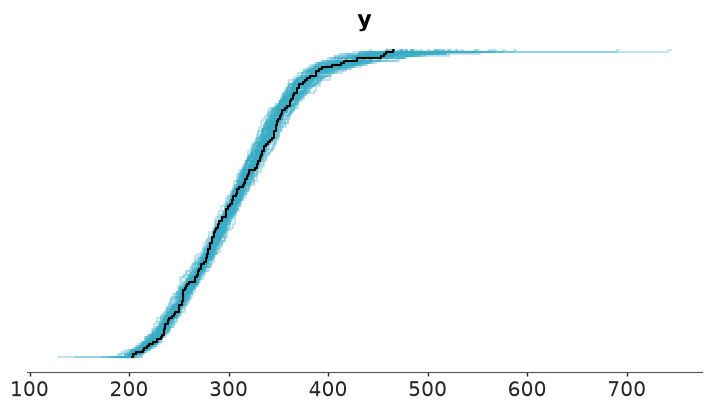

In [23]:
azp.plot_ppc_dist(
    idata,
    var_names=["y"],
    kind="ecdf",
    figure_kwargs={"figsize": (7, 4)},
);

### 5.8 Does the model reproduce the overall distribution, and can this check distinguish it from Notebook 7's model?

Broadly, yes. The observed ECDF lies within the spread of the posterior-predictive ECDFs across the whole distribution, with no persistent displacement in either tail.

It cannot distinguish the two models: Notebook 7's model passed this check too. The pooled ECDF ignores which participant produced which reaction time, and letting the residual scales differ mainly moves predictive variability from the steady participants to the variable ones rather than changing the overall distribution. The improvement shows only in the participant-level check (Question 5.5).

## 6. Summary

### 6.1 What has this notebook shown?

Summarize what letting the residual scale differ by participant showed about the model, the priors, sampling, the fitted residual scales, and the predictive checks.

- **Model.** A distributional model gives a likelihood parameter other than the location, here the residual scale, its own sub-model. Because a scale must be positive, the participants' residual scales are modeled on the log scale, with a centered hierarchy of the same form as those for `b0` and `b1`, and each observation uses its participant's scale through `sd_y[pidx]`.
- **Priors.** On the log scale, a center of zero is not neutral: it implies a residual scale of 1. The typical residual scale was centered on Notebook 7's estimate but kept broad enough for the data to determine it, and the prior for between-participant differences allows participants to differ several-fold. The prior predictive check looks much as it did in Notebook 7, apart from rare single-day spikes produced by the upper tail of the `sd_log_sd_y` prior.
- **Sampling.** Letting each participant's residual scale vary made the posterior harder to sample: how precisely a participant's intercept and slope are determined depends on that participant's uncertain residual scale. The centered parameterization sampled cleanly once `target_accept` was raised to 0.9.
- **Fitted residual scales.** A typical participant's residual scale is about 0.045–0.075, below Notebook 7's shared value, and participants differ substantially: the most variable participants have residual scales five to six times those of the steadiest. The data showed more between-participant variation than the prior expected.
- **Predictive checks.** The expected trajectories barely changed, but how precisely each is known now depends on the participant's variability. In the participant-level check, each participant's predictive bands now match their own day-to-day scatter, resolving the mismatch Notebook 7 left. The pooled ECDF is broadly consistent with the data, as it was in Notebook 7, and cannot tell the two models apart.